# Vahan.ai Assignment

Benchmarks Deepgram, Sarvam, and Whisper on self-recorded audio and FLEURS Hindi dataset.

# Readme
1. Install dependencies
2. Upload and convert audio
3. Define ground truth
4. API keys
5. Run all 3 models on your recordings
6. Run all 3 models on FLEURS dataset
7. Convert transcripts
8. Compute metrics for the recordings
9. Compute metrics for FLEURS dataset
10. Compare results
11. Charts


## 1. Installing Dependencies

In [25]:
!pip install deepgram-sdk==3.7.0 requests rapidfuzz jiwer pandas matplotlib indic-transliteration openai-whisper datasets soundfile -q
!apt install ffmpeg -q

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


## 2. Uploading and Converting Audio

In [2]:
!unzip audio_recording.zip
!ls audio_recording

Archive:  audio_recording.zip
   creating: audio_recording/
  inflating: audio_recording/banashankari.m4a  
  inflating: audio_recording/bellandur.m4a  
  inflating: audio_recording/btm_layout.m4a  
  inflating: audio_recording/electronic_city.m4a  
  inflating: audio_recording/hebbal.m4a  
  inflating: audio_recording/hesaraghatta.m4a  
  inflating: audio_recording/hsr_layout.m4a  
  inflating: audio_recording/indiranagar.m4a  
  inflating: audio_recording/jayanagar.m4a  
  inflating: audio_recording/koramangala.m4a  
  inflating: audio_recording/kr_puram.m4a  
  inflating: audio_recording/marathahalli.m4a  
  inflating: audio_recording/rajajinagar.m4a  
  inflating: audio_recording/rajarajeshwarinagar.m4a  
  inflating: audio_recording/sarjapur.m4a  
  inflating: audio_recording/silk_board.m4a  
  inflating: audio_recording/thalaghattapura.m4a  
  inflating: audio_recording/thanisandra.m4a  
  inflating: audio_recording/whitefield.m4a  
  inflating: audio_recording/yelahanka.m4a  
ba

In [3]:
import os

os.makedirs('audio_wav', exist_ok=True)

for f in os.listdir('audio_recording'):
    if f.endswith('.m4a'):
        out = f.replace('.m4a', '.wav')
        !ffmpeg -i "audio_recording/{f}" "audio_wav/{out}" -y -q 2

!ls audio_wav

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## 3. Actual Transcript
Entry format: name: (full sentence, locality name)

In [4]:
# what was said in the recordings
actual_sentences = {
    'koramangala':         ('bhai koramangala mein ek bahut accha cafe hai wahan chalte hain', 'koramangala'),
    'indiranagar':         ('hi bro i am near the indiranagar metro where are you', 'indiranagar'),
    'whitefield':          ('bhai mera naya office whitefield mein hai', 'whitefield'),
    'electronic_city':     ('whats the rent for a 2bhk in electronic city', 'electronic city'),
    'marathahalli':        ('bhai main marathahalli bus station pe hoon', 'marathahalli'),
    'jayanagar':           ('bhai jayanagar mein ek park bahut bada hai wahan pe ghoomne chalte hain', 'jayanagar'),
    'rajajinagar':         ('rajajinagar mein ek theatre hai chal wahan pe picture dekhne chalte hain', 'rajajinagar'),
    'hebbal':              ('bro i shifted to hebbal last month', 'hebbal'),
    'yelahanka':           ('main yelahanka mein rehta hoon bahut door hai tere yahan se', 'yelahanka'),
    'banashankari':        ('banashankari mein ek south indian restaurant hai wahan pe chalte hain', 'banashankari'),
    'hsr_layout':          ('hsr layout se silk board jaane wali bus kaunsi hai', 'hsr layout'),
    'btm_layout':          ('btm layout mein ek park hai wahan pe milte hain shaam ko', 'btm layout'),
    'silk_board':          ('silk board pe bahut traffic hai', 'silk board'),
    'bellandur':           ('i saw a flat in bellandur the rent is eighteen thousand', 'bellandur'),
    'sarjapur':            ('theres a good biryani place on sarjapur road', 'sarjapur'),
    'kr_puram':            ('i am at the kr puram station', 'kr puram'),
    'hesaraghatta':        ('bhai hesaraghatta road pe kaam chal raha hai', 'hesaraghatta'),
    'rajarajeshwarinagar': ('i found an affordable flat in rajarajeshwarinagar', 'rajarajeshwarinagar'),
    'thanisandra':         ('i have a meeting in thanisandra', 'thanisandra'),
    'thalaghattapura':     ('bro theres a restaurant in thalaghattapura', 'thalaghattapura'),
    }

print('Number of ', len(actual_sentences), 'sentences')

Number of  20 sentences


## 4. API Keys

In [29]:
import os
from getpass import getpass
os.environ['DEEPGRAM_API_KEY'] = getpass('Enter Deepgram API key: ')
os.environ['SARVAM_API_KEY']   = getpass('Enter Sarvam API key: ')

Enter Deepgram API key: ··········
Enter Sarvam API key: ··········


## 5. Running Models on Recordings

In [6]:
# MODEL 1: Deepgram
from deepgram import DeepgramClient, PrerecordedOptions
import time
client = DeepgramClient(os.environ['DEEPGRAM_API_KEY'])
deepgram_results = {}
for f in os.listdir('audio_wav'):
    name = f.replace('.wav', '')
    audio = open(f'audio_wav/{f}', 'rb').read()

    t = time.time()
    resp = client.listen.rest.v('1').transcribe_file(
        {'buffer': audio},
        PrerecordedOptions(model='nova-2', language='hi'))
    text = resp.results.channels[0].alternatives[0].transcript.lower().strip()
    deepgram_results[name] = {'transcript': text, 'latency': round(time.time()-t, 2)}
    print(name, ':', text)

btm_layout : bmt layout में एक park है वहां पर मिलते हैं शाम को
thalaghattapura : bro there is a restaurant in काला घटता पूरा
banashankari : banशंकरी में एक south indian restaurant है वहां पर चलते हैं
hsr_layout : एचएसr layout से silk road जाने वाली bus कौन सी है
whitefield : भाई मेरा नया office white field में है
silk_board : silk board पर बहुत traffic है
koramangala : भाई कोरमंगला में एक बहुत अच्छा cafe है वहां चलते हैं
indiranagar : hypro i am near the इंदिरा नगर metro where are you
electronic_city : was the rent for two bhk in electronic city
sarjapur : there's a good बिरयानी place on सरजापुर road
thanisandra : i have a meeting in thanishandrak
hebbal : bro i shifted to herbell last month
yelahanka : मैं यह लंका में रहता हूं बहुत दूर है तेरे यहां से
hesaraghatta : भाई है सरागट्टा road पर काम चल रहा है
rajarajeshwarinagar : found affordable flat in राजा राजेश्वरी नगर
bellandur : i saw a flat in बेलूर the rent is eighteen thousand
jayanagar : भाई जयनगर में एक park बहुत बड़ा है वहां प

In [10]:
# MODEL 2: Sarvam
import requests
sarvam_results = {}
for f in os.listdir('audio_wav'):
    name = f.replace('.wav', '')
    t = time.time()
    resp = requests.post(
        'https://api.sarvam.ai/speech-to-text',
        headers={'api-subscription-key': os.environ['SARVAM_API_KEY']},
        files={'file': (f, open(f'audio_wav/{f}', 'rb'), 'audio/wav')},
        data={'language_code': 'hi-IN', 'model': 'saaras:v3'})
    text = resp.json().get('transcript', '').lower().strip()
    sarvam_results[name] = {'transcript': text, 'latency': round(time.time()-t, 2)}
    print(name, ':', text)

btm_layout : बीएमटी लेआउट में एक पार्क है, वहाँ पर मिलते हैं शाम को।
thalaghattapura : ब्रो, देयर इज अ रेस्टोरेंट इन थाला गट्टापुरा।
banashankari : बैन शंकरी में एक साउथ इंडियन रेस्टोरेंट है, वहां पर चलते हैं।
hsr_layout : एचएसआर लेआउट से सिल्क रोड जाने वाली बस कौन सी है?
whitefield : भाई मेरा नया ऑफिस वाइट फील्ड में है।
silk_board : सिल्क बोर्ड पे बहुत ट्रैफिक है।
koramangala : भाई कोरमंगला में एक बहुत अच्छा कैफे है, वहाँ चलते हैं।
indiranagar : हाय ब्रो, आई एम नियर द इंदिरानगर मेट्रो, वेयर आर यू?
electronic_city : व्हाट्स द रेंट फॉर अ टू बीएचके इन इलेक्ट्रॉनिक सिटी?
sarjapur : देयर इज अ गुड बिरयानी प्लेस ऑन सरजापुर रोड।
thanisandra : आई हैव अ मीटिंग इन थानी स्वातंत्र्य।
hebbal : ब्रो, आई शिफ्टेड टू हेबल लास्ट मंथ।
yelahanka : मैं येलंका में रहता हूँ, बहुत दूर है तेरे यहाँ से।
hesaraghatta : भाई हेसराकट्टा रोड पे काम चल रहा है।
rajarajeshwarinagar : मैं एक अफोर्डेबल फ्लैट में राजा राजेश्वरी में आ गया।
bellandur : आई सॉ फ्लैट इन बेलेन्दूर, द रेंट इज ₹18000।
jayanagar : भाई, जयानगर में 

In [11]:
# MODEL 3: Whisper
import whisper
wmodel = whisper.load_model('medium')
whisper_results = {}
for f in os.listdir('audio_wav'):
    name = f.replace('.wav', '')
    result = wmodel.transcribe(f'audio_wav/{f}', language='hi')
    whisper_results[name] = {'transcript': result['text'].lower().strip()}
    print(name, ':', whisper_results[name]['transcript'])

100%|█████████████████████████████████████| 1.42G/1.42G [00:21<00:00, 72.8MiB/s]
/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


btm_layout : बीम्टी लेयौट में एक पार के वाह पे मिलते हैं शाम्प के लेए


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


thalaghattapura : ब्रो देज रेस्ट्टुन्टिन थाला गट्ट पूरा


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


...

marathahalli : बाई मैं मराथ हली बर्स्टेशन पे हूँ


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


rajajinagar : राज़ेजीनगर में एक थेटर है चल वाप पे पिट्चर देखने शाथे हैं।


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


kr_puram : अपने कर पूरम्ष्टेशण के लिए पावार।


## 6. Running Models on FLEURS Dataset
20 samples of clean Hindi audio; used to compare performance on noise-free speech vs the recordings.

In [13]:
# load FLEURS Dataset
from datasets import load_dataset
import soundfile as sf
os.makedirs('fleurs_audio', exist_ok=True)
dataset = load_dataset('google/fleurs', 'hi_in', split='test', streaming=True)
fleurs_refs = {}
for i, row in enumerate(dataset):
    if i >= 20:
        break
    sf.write(f'fleurs_audio/fleurs_{i}.wav', row['audio']['array'], row['audio']['sampling_rate'])
    fleurs_refs[f'fleurs_{i}'] = row['transcription'].lower().strip()
    print(i, ':', row['transcription'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

0 : कुछ अणुओं में अस्थिर केंद्रक होता है जिसका मतलब यह है कि उनमें थोड़े या बिना किसी झटके से टूटने की प्रवृत्ति होती है
1 : ग्रीनलैंड को बहुत कम जगह बसाया गया था नॉर्स सगास में वे कहते हैं कि एरिक रेड हत्या के लिए आइसलैंड से निर्वासित किया गया था और आगे पश्चिम की यात्रा करते समय ग्रीनलैंड मिला जिसे ग्रीनलैंड नाम दिया गया
2 : ऐसी कोई वैश्विक परिभाषा नहीं है जिसके लिए निर्मित सामान एंटीक होते हैं कुछ कर एजेंसियां 100 साल से पुराने सामान को एंटीक के तौर पर परिभाषित करती हैं
3 : टेलीविजन रिपोर्टों में प्लांट से निकलने वाला सफेद धुआं दिखाया गया है
4 : इंटरनेट पर यह खोज शत्रुतापूर्ण पर्यावरण पाठ्यक्रम के लिए अक्सर आपको एक स्थानीय कंपनी का पता प्रदान करेगी
5 : अपनी सरकार के अलावा आप अन्य देशों की सरकारों की सलाह ले सकते हैं हालांकि उनकी सलाह उनके नागरिकों को ध्यान में रखकर दी जाती हैं
6 : प्राचीनकाल से ही लोग सोने चांदी और तांबे जैसे रासायनिक तत्वों के बारे में ही जानकारी रखते हैं क्योंकि इन्हें प्रकृति में मूल स्वरूप में ढूंढा जा सकता है और इन्हें प्राथमिक उपकरणों के ज़रिए ढूंढना अपेक्षाकृत

In [14]:
# Model 1: Deepgram on FLEURS
fleurs_deepgram = {}
for f in os.listdir('fleurs_audio'):
    name = f.replace('.wav', '')
    audio = open(f'fleurs_audio/{f}', 'rb').read()
    t = time.time()
    resp = client.listen.rest.v('1').transcribe_file(
        {'buffer': audio},
        PrerecordedOptions(model='nova-2', language='hi'))
    text = resp.results.channels[0].alternatives[0].transcript.lower().strip()
    fleurs_deepgram[name] = {'transcript': text, 'latency': round(time.time()-t, 2)}
    print(name, ':', text)

fleurs_1 : england को बहुत कम जगह बसाया गया था notes सगा समय वे कहते हैं कि एक रेड हत्या के लिए आइसलैंड से निर्वासित किया गया था और आगे पश्चिम की यात्रा करते समय ग्रीनलैंड मिला जिसे ग्रीनलैंड नाम दिया गया
fleurs_12 : m.s बीमारी केंद्रीय तंत्रिका तंत्र पर असर करती है जिसमें दिमाग स्पाइनल card और optic नर्व शामिल हैं
fleurs_15 : विशेष रूप से सवाना पर बेहतरीन अफ्रीकी वन्य जीवन को संपूर्ण रूप से देखने के लिए आमतौर पर सफारी शब्द का उपयोग किया जाता है
fleurs_8 : सबसे नज़दीकी सिरे पर कष्ट की मोटाई करीब सत्तर kilometer है और सबसे दूर के सिरे पर यह सौ kilometer है
fleurs_10 : पुरुषों के स्टैंडिंग super जी में australia के मिशेल गौरले ग्यारहवें स्थान पर रहे check प्रतियोगी ओल्डरीच जेलिनक पुरुषों के setting super जी में सोल्वे स्थान पर रहे
fleurs_13 : हर कोई समाज से जुड़ा होता है और ट्रांसपोर्ट system का उपयोग करता है लगभग सभी लोग ट्रांसपोर्ट system के बारे में शिकायत करते हैं
fleurs_0 : कुछ अणुओं में अनिश्चित केंद्रक होता है जिसका मतलब यह कि उनमें थोड़े या बिना किसी झटके से टूटने की प्रवृत्ति हो

In [15]:
# Model 2: Sarvam on FLEURS
fleurs_sarvam = {}
for f in os.listdir('fleurs_audio'):
    name = f.replace('.wav', '')
    t = time.time()
    resp = requests.post(
        'https://api.sarvam.ai/speech-to-text',
        headers={'api-subscription-key': os.environ['SARVAM_API_KEY']},
        files={'file': (f, open(f'fleurs_audio/{f}', 'rb'), 'audio/wav')},
        data={'language_code': 'hi-IN', 'model': 'saaras:v3'} )
    text = resp.json().get('transcript', '').lower().strip()
    fleurs_sarvam[name] = {'transcript': text, 'latency': round(time.time()-t, 2)}
    print(name, ':', text)

fleurs_1 : ग्रीनलैंड को बहुत कम जगह बसाया गया था। नॉर्स सगास में वे कहते हैं कि एरिक रेड हत्या के लिए आइसलैंड से निर्वासित किया गया था और आगे पश्चिम की यात्रा करते समय ग्रीनलैंड मिला जिसे ग्रीनलैंड नाम दिया गया।
fleurs_12 : एम एस बीमारी केंद्रीय तंत्रिका तंत्र पर असर करती है जिसमें दिमाग, स्पाइनल कॉर्ड और ऑप्टिक नर्व शामिल हैं।
fleurs_15 : विशेष रूप से सवाना पर बेहतरीन अफ्रीकी वन्य जीवन को संपूर्ण रूप से देखने के लिए आमतौर पर सफारी शब्द का उपयोग किया जाता है।
fleurs_8 : सबसे नज़दीकी सिरे पर क्रिस्ट की मोटाई करीब 70 किलोमीटर है और सबसे दूर के सिरे पर यह 100 किलोमीटर है।
fleurs_10 : पुरुषों के स्टैंडिंग सुपर जी में ऑस्ट्रेलिया के मिशेल गॉर्ले ग्यारहवें स्थान पर रहे। चेक प्रतियोगी ऑल्ड्रिच जेलिनेक पुरुषों के सिटिंग सुपर जी में सोलहवें स्थान पर रहे।
fleurs_13 : हर कोई समाज से जुड़ा होता है और ट्रांसपोर्ट सिस्टम का उपयोग करता है। लगभग सभी लोग ट्रांसपोर्ट सिस्टम के बारे में शिकायत करते हैं।
fleurs_0 : कुछ अणुओं में अस्थिर केंद्रक होता है जिसका मतलब यह कि उनमें थोड़े या बिना किसी झटके से टूटन

In [16]:
# Model 3: Whisper on FLEURS
fleurs_whisper = {}
for f in sorted(os.listdir('fleurs_audio')):
    name = f.replace('.wav', '')
    t = time.time()
    result = wmodel.transcribe('fleurs_audio/'+f, language='hi')
    text = result['text'].lower().strip()
    fleurs_whisper[name] = {'transcript': text, 'latency': round(time.time()-t, 2)}
    print(name, ':', text)

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


fleurs_0 : कुछ अड़ोंगों में आर्स्तर केंद्रक होता है जिसका मतलब यहां कि उन्में थोड़े या बिना किसी जट्के से तूटने की प्रवत्ती होती है


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


fleurs_1 : ग्रीनलेंड को भुत कम जगव बसाया गया था। नौर्स सगास में वे कहते हैं कि एरिक रेड हत्या के लिए आइसलेंड से निर्वासित किया गया था। और आगे परश्चम की यात्र करते समय ग्रीनलेंड मिला जिसे ग्रीनलेंड नाम दिया गया।


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


...

fleurs_7 : इसे कैमिकल का प्येज कहा जाता है आप लाल गोबी के जॉस को इस्तमाल करके एक संके तक बना सकते हैं


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


fleurs_8 : सबसे नज़ी के सिरे पर कृष्ट की मोटाई करेव 70 किलोमेटर है और सबसे दूर के सिरे पर यह 100 किलोमेटर है


/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


fleurs_9 : यह सममनदत है लेकिन आमतोर पर इसमें आलपायन शैली की सकीट टूरिंग यह माॉन्टेन ये रिंग सामिल नहीं होती हैं जिसे खड़े इलागपों में किया जाता है और जिसके लिए बहुत कड़ी सकी और बूट की जरूरत होती है


## 7. Convert Transcripts
All three models return text in Hindi (Devanagari script) but our benchmark sentences are written in English letters. So we convert the model output to English letters before comparing.
This conversion isn't perfect because our recordings mix Hindi and English in the same sentence. So the metrics are rough comparisons, not exact scores.

In [17]:
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate
def to_roman(text):
    try:
        return transliterate(text, sanscript.DEVANAGARI, sanscript.ITRANS).lower().strip()
    except:
        return text.lower().strip()
# convert all transcripts to roman
all_results = [deepgram_results, sarvam_results, whisper_results, fleurs_deepgram, fleurs_sarvam, fleurs_whisper]
for result_dict in all_results:
    for name in result_dict:
        result_dict[name]['transcript'] = to_roman(result_dict[name]['transcript'])
for name in fleurs_refs:
    fleurs_refs[name] = to_roman(fleurs_refs[name])
# debug
print('deepgram:', deepgram_results['koramangala']['transcript'])
print('sarvam:', sarvam_results['koramangala']['transcript'])
print('whisper:', whisper_results['koramangala']['transcript'])

deepgram: bhai koramamgala mem eka bahuta achcha cafe hai vaham chalate haim
sarvam: bhai koramamgala mem eka bahuta achcha kaiphe hai, vaha.n chalate haim|
whisper: bai kora mamgala mem eka bauta ichcha kaphe vaha.n chalate haim


## 8. Metric Functions

We use 7 metrics to evaluate each model.

**1. WER**: how many words were wrong in the full sentence

**2. MER**: similar to WER but fairer, doesn't penalise short sentences as harshly

**3. WIL**: how much information from the original sentence was lost

**4. NE-WER**: WER calculated only on the locality name, not the whole sentence.

**5. Jaro-Winkler**: fuzzy similarity score for the locality name. Catches near misses like "herbell" vs "hebbal" that WER would just mark as wrong

**6. ERUN**: did the model capture the locality name well enough to be usable?

**7. Hallucination**: did the model output something completely unrelated to what was said? Flagged when less than 10% of words overlap with the reference


In [18]:
import jiwer
from rapidfuzz.distance import JaroWinkler

def get_wer(reference, hypothesis):
    if not hypothesis: return 1.0
    return round(jiwer.wer(reference, hypothesis), 4)

def get_mer(reference, hypothesis):
    if not hypothesis: return 1.0
    return round(jiwer.mer(reference, hypothesis), 4)

def get_wil(reference, hypothesis):
    if not hypothesis: return 1.0
    return round(jiwer.wil(reference, hypothesis), 4)

def get_ne_wer(entity, hypothesis):
    # wer on just the locality name using sliding window
    if not hypothesis: return 1.0
    entity_words = entity.split()
    hyp_words = hypothesis.split()
    window_size = len(entity_words)

    if len(hyp_words) < window_size:
        return round(jiwer.wer(entity, hypothesis), 4)
    best_score = 1.0
    for i in range(len(hyp_words) - window_size + 1):
        window = ' '.join(hyp_words[i:i+window_size])
        score = jiwer.wer(entity, window)
        if score < best_score:
            best_score = score
    return round(best_score, 4)

def get_jaro(entity, hypothesis):
    # fuzzy match on locality name
    if not hypothesis: return 0.0
    entity_words = entity.split()
    hyp_words = hypothesis.split()
    window_size = len(entity_words)

    if len(hyp_words) < window_size:
        return round(JaroWinkler.similarity(entity, hypothesis), 4)

    best_score = 0.0
    for i in range(len(hyp_words) - window_size + 1):
        window = ' '.join(hyp_words[i:i+window_size])
        score = JaroWinkler.similarity(entity, window)
        if score > best_score:
            best_score = score
    return round(best_score, 4)

def is_hallucination(reference, hypothesis):
    # less than 10% word overlap means hallucination
    if not hypothesis: return False
    overlap = set(reference.split()) & set(hypothesis.split())
    return len(overlap) / len(reference.split()) < 0.10

Metrics done.


## 9. Compute Metrics For The Recordings

In [19]:
import pandas as pd
rows = []
for name in actual_sentences:
    reference, entity = actual_sentences[name]
    dg = deepgram_results.get(name, {}).get('transcript', '')
    sv = sarvam_results.get(name, {}).get('transcript', '')
    ws = whisper_results.get(name, {}).get('transcript', '')
    rows.append({
        'file': name,
        'reference': reference,
        'entity': entity,

        'dg_transcript': dg,
        'dg_wer': get_wer(reference, dg),
        'dg_mer': get_mer(reference, dg),
        'dg_wil': get_wil(reference, dg),
        'dg_ne_wer': get_ne_wer(entity, dg),
        'dg_jaro': get_jaro(entity, dg),
        'dg_erun': get_jaro(entity, dg) >= 0.80,
        'dg_hallucination': is_hallucination(reference, dg),
        'dg_latency': deepgram_results.get(name, {}).get('latency'),

        'sv_transcript': sv,
        'sv_wer': get_wer(reference, sv),
        'sv_mer': get_mer(reference, sv),
        'sv_wil': get_wil(reference, sv),
        'sv_ne_wer': get_ne_wer(entity, sv),
        'sv_jaro': get_jaro(entity, sv),
        'sv_erun': get_jaro(entity, sv) >= 0.80,
        'sv_hallucination': is_hallucination(reference, sv),
        'sv_latency': sarvam_results.get(name, {}).get('latency'),

        'ws_transcript': ws,
        'ws_wer': get_wer(reference, ws),
        'ws_mer': get_mer(reference, ws),
        'ws_wil': get_wil(reference, ws),
        'ws_ne_wer': get_ne_wer(entity, ws),
        'ws_jaro': get_jaro(entity, ws),
        'ws_erun': get_jaro(entity, ws) >= 0.80,
        'ws_hallucination': is_hallucination(reference, ws),
        'ws_latency': whisper_results.get(name, {}).get('latency'),})
results = pd.DataFrame(rows)
results.to_csv('results_raw.csv', index=False)

saved results_raw.csv


## 10. Compute Metrics For FLEURS Dataset

In [20]:
fleurs_rows = []
for name in fleurs_refs:
    reference = fleurs_refs[name]
    dg = fleurs_deepgram.get(name, {}).get('transcript', '')
    sv = fleurs_sarvam.get(name, {}).get('transcript', '')
    ws = fleurs_whisper.get(name, {}).get('transcript', '')
    fleurs_rows.append({
        'file':             name,
        'dg_wer':           get_wer(reference, dg),
        'dg_hallucination': is_hallucination(reference, dg),
        'sv_wer':           get_wer(reference, sv),
        'sv_hallucination': is_hallucination(reference, sv),
        'ws_wer':           get_wer(reference, ws),
        'ws_hallucination': is_hallucination(reference, ws),})
fleurs_results = pd.DataFrame(fleurs_rows)
fleurs_results.to_csv('results_fleurs.csv', index=False)

saved results_fleurs.csv


## 11. Compare Results

In [21]:
models = [('Deepgram', 'dg'), ('Sarvam', 'sv'), ('Whisper', 'ws')]
print('MY RECORDINGS')
print('-' * 40)
for model_name, prefix in models:
    print(model_name)
    print('WER:', round(results[prefix+'_wer'].mean(), 3))
    print('MER:', round(results[prefix+'_mer'].mean(), 3))
    print('WIL:', round(results[prefix+'_wil'].mean(), 3))
    print('NE-WER:', round(results[prefix+'_ne_wer'].mean(), 3))
    print('Jaro:', round(results[prefix+'_jaro'].mean(), 3))
    print('ERUN:', round(results[prefix+'_erun'].mean()*100, 1), '%')
    print('Hallucination:', round(results[prefix+'_hallucination'].mean()*100, 1), '%')
    print('Latency:', round(results[prefix+'_latency'].dropna().mean(), 2), 'sec')
    print()
print('FLEURS (clean hindi, 20 samples)')
print('-' * 40)
for model_name, prefix in models:
    print(model_name)
    print('WER:', round(fleurs_results[prefix+'_wer'].mean(), 3))
    print('Hallucination:', round(fleurs_results[prefix+'_hallucination'].mean()*100, 1), '%')
    print()

MY RECORDINGS
----------------------------------------
Deepgram
WER: 0.546
MER: 0.492
WIL: 0.669
NE-WER: 0.85
Jaro: 0.883
ERUN: 80.0 %
Hallucination: 0.0 %
Latency: 0.97 sec

Sarvam
WER: 0.988
MER: 0.896
WIL: 0.974
NE-WER: 1.0
Jaro: 0.837
ERUN: 70.0 %
Hallucination: 50.0 %
Latency: 2.2 sec

Whisper
WER: 0.935
MER: 0.9
WIL: 0.965
NE-WER: 1.0
Jaro: 0.765
ERUN: 55.0 %
Hallucination: 55.0 %
Latency: nan sec

FLEURS (clean hindi, 20 samples)
----------------------------------------
Deepgram
WER: 0.149
Hallucination: 0.0 %

Sarvam
WER: 0.129
Hallucination: 0.0 %

Whisper
WER: 0.432
Hallucination: 0.0 %



## 12. Charts

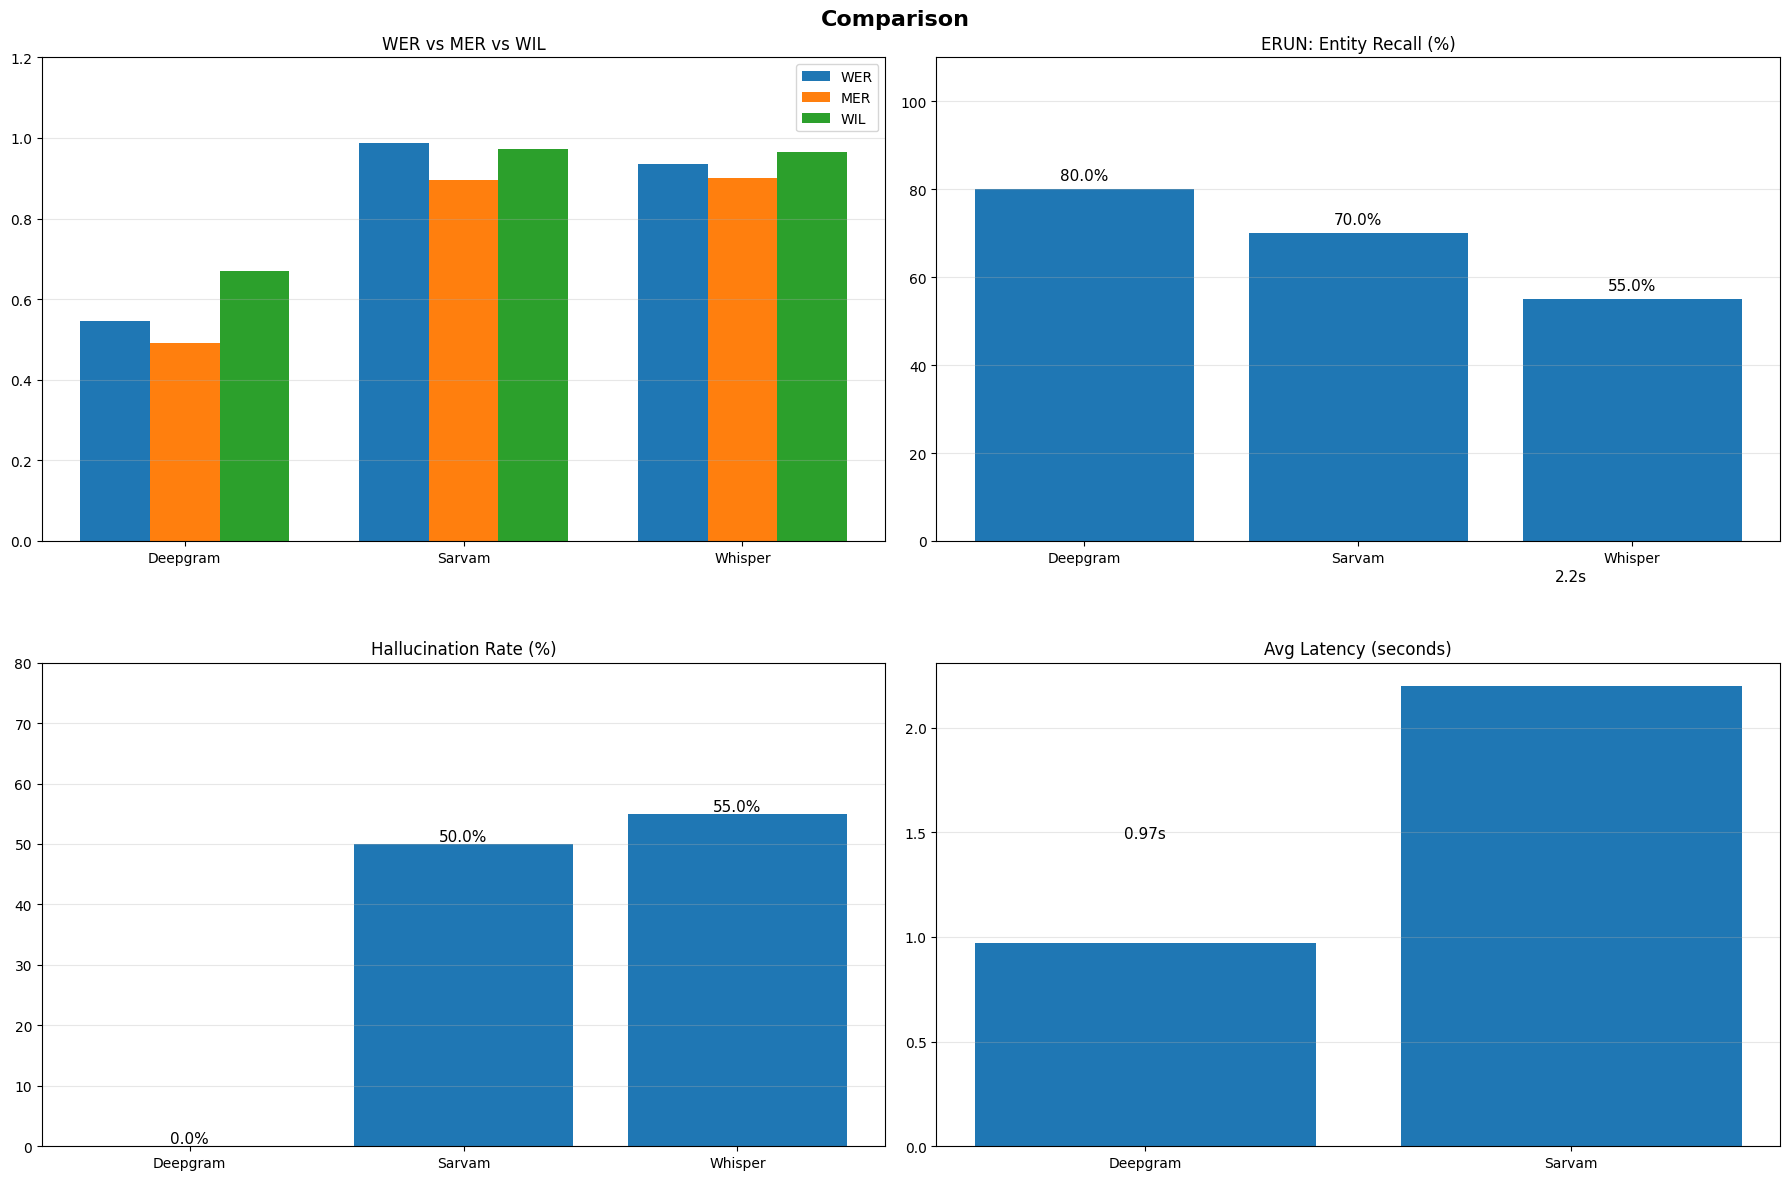

Saved results_charts.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ['Deepgram', 'Sarvam', 'Whisper']
prefixes = ['dg', 'sv', 'ws']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Comparison', fontweight='bold', fontsize=16)

#wer vs mer vs wil
x = np.arange(len(model_names))
bar_width = 0.25

wer_vals = [results[p+'_wer'].mean() for p in prefixes]
mer_vals = [results[p+'_mer'].mean() for p in prefixes]
wil_vals = [results[p+'_wil'].mean() for p in prefixes]

axes[0][0].bar(x - bar_width, wer_vals, bar_width, label='WER')
axes[0][0].bar(x, mer_vals, bar_width, label='MER')
axes[0][0].bar(x + bar_width, wil_vals, bar_width, label='WIL')
axes[0][0].set_title('WER vs MER vs WIL')
axes[0][0].set_xticks(x)
axes[0][0].set_xticklabels(model_names)
axes[0][0].set_ylim(0, 1.2)
axes[0][0].legend()
axes[0][0].grid(axis='y', alpha=0.3)
#erun
erun_vals = [round(results[p+'_erun'].mean()*100, 1) for p in prefixes]
axes[0][1].bar(model_names, erun_vals)
axes[0][1].set_title('ERUN: Entity Recall (%)')
axes[0][1].set_ylim(0, 110)
axes[0][1].grid(axis='y', alpha=0.3)
for i, val in enumerate(erun_vals):
    axes[0][1].text(i, val+2, str(val)+'%', ha='center', fontsize=11)
# hallucination
hallucination_vals = [round(results[p+'_hallucination'].mean()*100, 1) for p in prefixes]
axes[1][0].bar(model_names, hallucination_vals)
axes[1][0].set_title('Hallucination Rate (%)')
axes[1][0].set_ylim(0, 80)
axes[1][0].grid(axis='y', alpha=0.3)
for i, val in enumerate(hallucination_vals):
    axes[1][0].text(i, val+0.5, str(val)+'%', ha='center', fontsize=11)
# latency
latency_vals = [round(results[p+'_latency'].dropna().mean(), 2) for p in prefixes]
axes[1][1].bar(model_names, latency_vals)
axes[1][1].set_title('Avg Latency (seconds)')
axes[1][1].grid(axis='y', alpha=0.3)
for i, val in enumerate(latency_vals):
    axes[1][1].text(i, val+0.5, str(val)+'s', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('results_charts.png', dpi=150)
plt.show()
print('Saved results_charts.png')

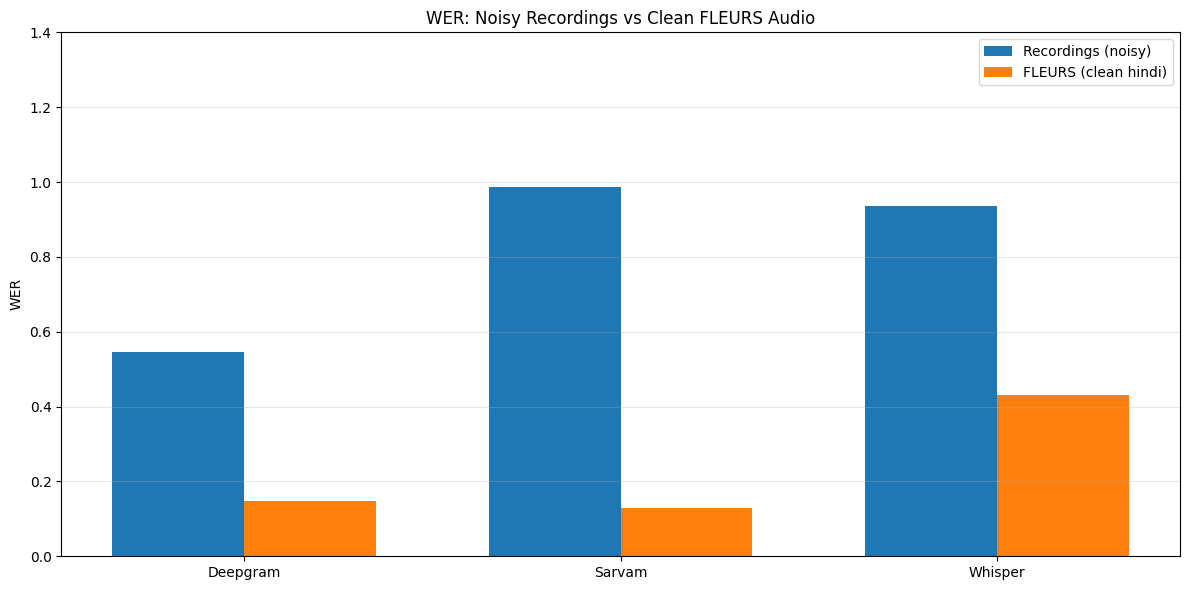

Saved noisy_vs_clean.png


In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(model_names))
bar_width = 0.35

noisy_wer = [round(results[p+'_wer'].mean(), 3) for p in prefixes]
clean_wer = [round(fleurs_results[p+'_wer'].mean(), 3) for p in prefixes]

ax.bar(x - bar_width/2, noisy_wer, bar_width, label='Recordings (noisy)')
ax.bar(x + bar_width/2, clean_wer, bar_width, label='FLEURS (clean hindi)')

ax.set_title('WER: Noisy Recordings vs Clean FLEURS Audio')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('WER')
ax.set_ylim(0, 1.4)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('noisy_vs_clean.png', dpi=150)
plt.show()
print('Saved noisy_vs_clean.png')